# **¿Qué es una Cámara de Niebla?**

La cámara de niebla, inventada por Charles Wilson a comienzos del siglo XX, es un dispositivo diseñado para hacer visibles las trayectorias de partículas cargadas, como electrones, protones o rayos cósmicos, que normalmente resultan imposibles de observar a simple vista. Su funcionamiento se basa en el uso de un ambiente cerrado que contiene vapor de alcohol en estado de sobresaturación. Cuando una partícula cargada atraviesa la cámara, interactúa con las moléculas de aire y las ioniza a lo largo de su recorrido. Estos iones actúan como núcleos de condensación alrededor de los cuales el vapor se transforma en diminutas gotitas, generando una fina estela visible. De esta manera, lo que observamos en la cámara no es la partícula en sí, sino la huella que deja su paso en forma de pequeñas líneas de condensación. Según el tipo de partícula, su energía y las condiciones internas del dispositivo, estas trazas pueden aparecer más rectas, curvas o dispersas, ofreciendo información valiosa sobre el fenómeno físico. En esencia, la cámara de niebla convierte el paso invisible de las partículas en un espectáculo visual, permitiendo que la física subatómica pueda ser percibida de manera directa y experimental.

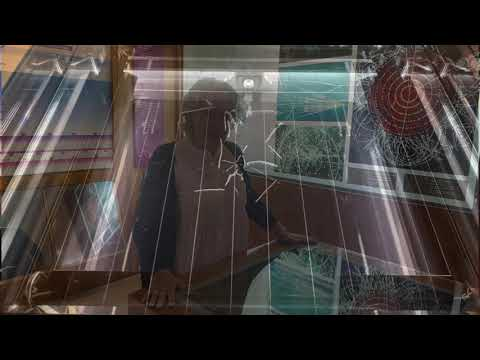

In [3]:
from IPython.display import YouTubeVideo

# Identificador del video — para el enlace que me diste es “Sj3LK5XZ3Lo”
video = YouTubeVideo("Sj3LK5XZ3Lo", width=640, height=360)

display(video)

In [2]:
#Obtención de la data
from LHC import experiment_CMS
experiment_CMS(num_img=500, size=64, zip_name="CERN_dataset")

Dataset generado con 500 imágenes por clase.
Archivo comprimido: CERN_dataset.zip


In [3]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def cargar_datos(zip_path="CERN_dataset.zip", carpeta_salida="CERN_datos"):
    #1. Proceso para descomprimir el archivo ZIP
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(carpeta_salida)
    X = []
    y = []
    #2. Recorrer las carpetas con las imagenes
    for clase in os.listdir(carpeta_salida):
        clase_path = os.path.join(carpeta_salida, clase)
        if os.path.isdir(clase_path):
            for img_name in os.listdir(clase_path):
                img_path = os.path.join(clase_path, img_name)

                # 3. Procedimiento para cargar imagenes en escala de grises
                img = Image.open(img_path).convert("L")
                X.append(np.array(img))
                y.append(clase)  # etiqueta = nombre de la carpeta

    X = np.array(X)
    return X, y

In [4]:
X, y = cargar_datos("CERN_dataset.zip")
print(f"Se cargaron {len(X)} imágenes.")
print(f"Clases encontradas: {set(y)}")
print("Dimensiones de las imágenes:", X.shape)

Se cargaron 3000 imágenes.
Clases encontradas: {'proton', 'electron', 'muon', 'quark', 'neutrino', 'tau'}
Dimensiones de las imágenes: (3000, 64, 64)


In [5]:
X[1]

array([[  0,   0, 255, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0, 255,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [255,   0,   0, ...,   0,   0,   0]], dtype=uint8)

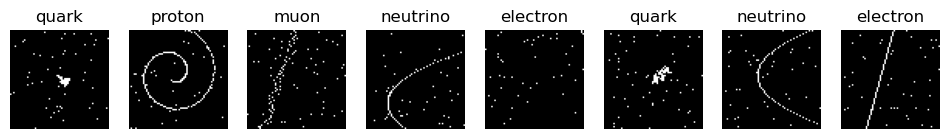

In [6]:
def mostrar_imagenes(X, y, n=6):
    indices = np.random.choice(len(X), n, replace=False)  # elegir imagen aleatoriamente
    plt.figure(figsize=(12, 4))

    for i, idx in enumerate(indices):
        plt.subplot(1, n, i+1)
        plt.imshow(X[idx], cmap="gray")
        plt.title(y[idx])
        plt.axis("off")
    plt.show()

mostrar_imagenes(X, y, n=8)

In [7]:
np.set_printoptions(threshold=np.inf)
print(X[0])
print("Etiqueta:", y[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 255   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0 255   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 255
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 255   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 255   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0

## **Taller: Clasificación de Trazas de Partículas**

Construya un clasificador supervisado capaz de diferenciar entre distintos tipos de partículas a partir de imágenes de sus trazas. Para ello, se trabajará con el conjunto de datos previamente cargado, organizadas en carpetas según la clase de partícula correspondiente:

*   Electrón
*   Muón
*   Protón
*   Neutrino
*   Quark
*   Tau

Desarrolle un flujo completo de trabajo en aprendizaje automático, desde la carga y exploración de los datos hasta la evaluación de un modelo de clasificación. El ejercicio permitirá comprender los principales pasos de un proyecto de machine learning aplicado al análisis de imágenes.

1. Carga de datos.
2. Exploración inicial: Se deberán mostrar algunas imágenes representativas de cada clase, imprimir las dimensiones de X y y, y analizar la distribución de las clases en el conjunto de datos.
3. Será necesario normalizar los valores de los píxeles en el rango [0, 1], preparar los datos para el modelo y dividirlos en conjuntos de entrenamiento y prueba (por ejemplo, 80% entrenamiento y 20% prueba).
4. Implemente al menos un modelo de clasificación supervisada. Se recomienda iniciar con modelos clásicos como: Regresión Logística y SVM.
5. Evaluación del modelo: El desempeño del clasificador deberá medirse calculando la precisión en el conjunto de prueba. Además, se deberá generar una matriz de confusión para analizar qué clases resultan más fáciles o difíciles de distinguir. Pueden calcular métricas adicionales como la exactitud por clase o las curvas ROC.
6. Discusión y conclusiones: Finalmente, deberá presentar una reflexión sobre los resultados obtenidos, identificando fortalezas y debilidades del clasificador. También deberá proponer mejoras posibles.

In [8]:
# Paso 1: Carga de datos
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from collections import Counter

# Función para cargar imágenes
def load_image_dataset(root_dir, size=(64,64), max_per_class=None):
    X, y = [], []
    classes = sorted(os.listdir(root_dir))
    for cls in classes:
        cls_path = os.path.join(root_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png','.jpg'))]
        if max_per_class:
            files = files[:max_per_class]
        for f in files:
            img = imread(os.path.join(cls_path, f))
            if img.ndim == 3:  # convertir a escala de grises si es RGB
                img = img[...,0]
            img_resized = resize(img, size, anti_aliasing=True)
            X.append(img_resized)
            y.append(cls)
    return np.array(X), np.array(y), classes

# Cambia la ruta por la carpeta donde tengas las imágenes
X, y, classes = load_image_dataset("CMS_data", size=(32,32))
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases:", classes)


Shape de X: (3000, 32, 32)
Shape de y: (3000,)
Clases: ['electron', 'muon', 'neutrino', 'proton', 'quark', 'tau']


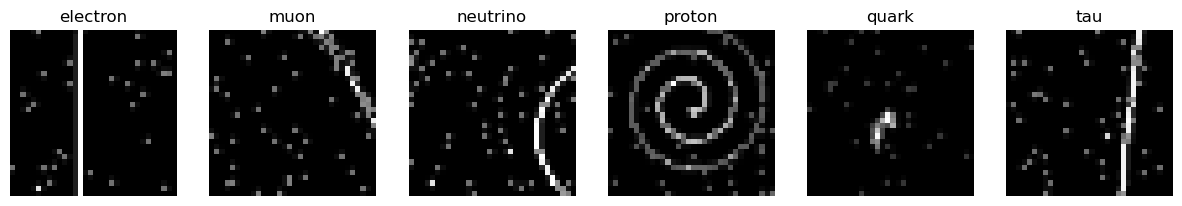

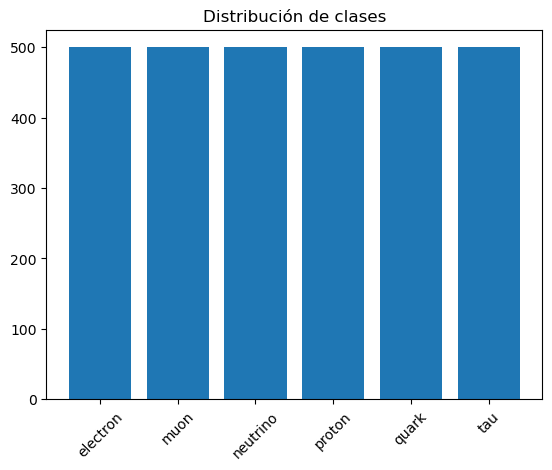

In [9]:
# Paso 2: Exploración inicial
# Mostrar algunas imágenes representativas por clase
fig, axes = plt.subplots(1, len(classes), figsize=(15,4))
for i, cls in enumerate(classes):
    idx = np.where(y == cls)[0][0]  # primer ejemplo de esa clase
    axes[i].imshow(X[idx], cmap="gray")
    axes[i].set_title(cls)
    axes[i].axis("off")
plt.show()

# Distribución de clases
conteo = Counter(y)
plt.bar(conteo.keys(), conteo.values())
plt.xticks(rotation=45)
plt.title("Distribución de clases")
plt.show()


In [10]:
# Paso 3: Normalización y división de datos
# Normalizar al rango [0,1]
X = X / X.max()

# Aplanar imágenes para modelos clásicos
X_flat = X.reshape(len(X), -1)

# División train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, stratify=y, random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (2400, 1024) Test: (600, 1024)


In [11]:
# Paso 4a: Modelo clásico - Regresión Logística
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000, solver="lbfgs", multi_class="auto")
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy Regresión Logística:", accuracy_score(y_test, y_pred_lr))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_lr))


Accuracy Regresión Logística: 0.575

Reporte de clasificación:
               precision    recall  f1-score   support

    electron       0.36      0.36      0.36       100
        muon       0.35      0.35      0.35       100
    neutrino       0.40      0.42      0.41       100
      proton       1.00      0.99      0.99       100
       quark       1.00      0.93      0.96       100
         tau       0.38      0.40      0.39       100

    accuracy                           0.57       600
   macro avg       0.58      0.58      0.58       600
weighted avg       0.58      0.57      0.58       600



In [12]:
# Paso 4b: Modelo clásico - SVM
from sklearn.svm import SVC

svm_clf = SVC(kernel="rbf", C=10, gamma="scale")
svm_clf.fit(X_train, y_train)

y_pred_svm = svm_clf.predict(X_test)

print("Accuracy SVM:", accuracy_score(y_test, y_pred_svm))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred_svm))


Accuracy SVM: 0.7816666666666666

Reporte de clasificación:
               precision    recall  f1-score   support

    electron       0.55      0.46      0.50       100
        muon       0.69      0.70      0.70       100
    neutrino       0.72      0.75      0.74       100
      proton       0.99      1.00      1.00       100
       quark       1.00      0.99      0.99       100
         tau       0.71      0.79      0.75       100

    accuracy                           0.78       600
   macro avg       0.78      0.78      0.78       600
weighted avg       0.78      0.78      0.78       600



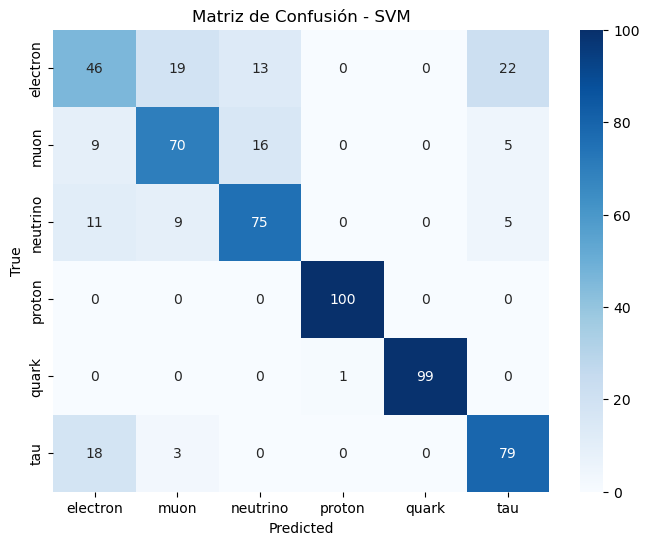

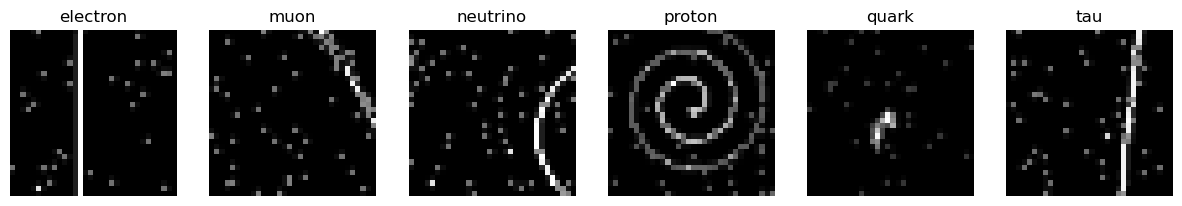

In [13]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm, labels=classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Matriz de Confusión - SVM")
plt.show()

fig, axes = plt.subplots(1, len(classes), figsize=(15,4))
for i, cls in enumerate(classes):
    idx = np.where(y == cls)[0][0]  # primer ejemplo de esa clase
    axes[i].imshow(X[idx], cmap="gray")
    axes[i].set_title(cls)
    axes[i].axis("off")
plt.show()


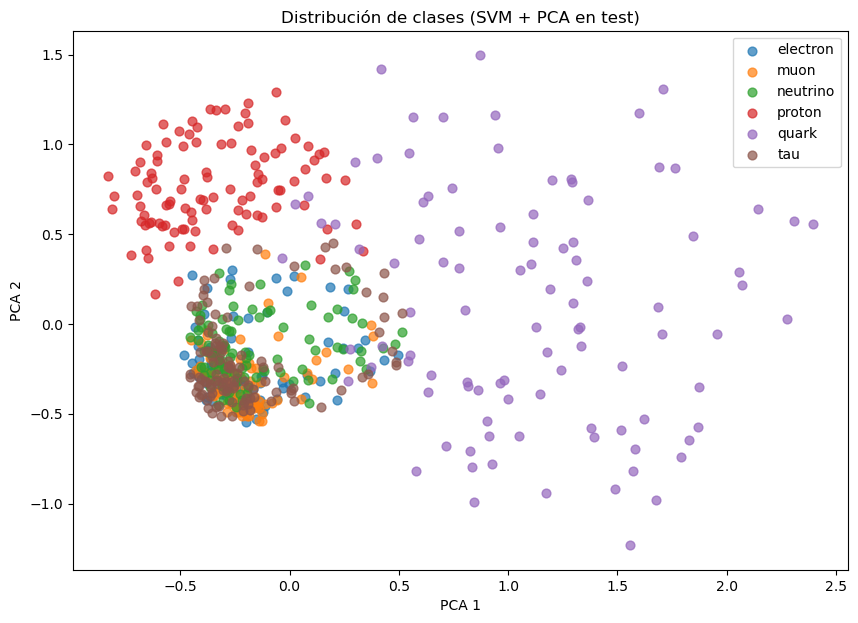

In [14]:
from sklearn.decomposition import PCA

# Reducimos datos de test a 2D para visualizar
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test)

# Predicciones del modelo entrenado
y_pred = svm_clf.predict(X_test)

# Graficamos: puntos coloreados por la clase predicha
plt.figure(figsize=(10,7))
for i, cls in enumerate(classes):
    idx = np.where(y_pred == cls)
    plt.scatter(X_test_pca[idx, 0], X_test_pca[idx, 1], label=cls, s=40, alpha=0.7)

plt.title("Distribución de clases (SVM + PCA en test)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()



Forma original (PCA): (2400, 2)
Forma transformada (Poly): (2400, 6)


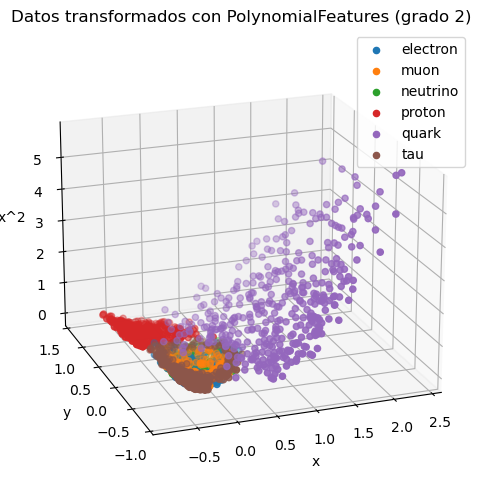

In [15]:
from sklearn.preprocessing import PolynomialFeatures
from mpl_toolkits.mplot3d import Axes3D

# Tomamos los datos reducidos a 2D con PCA
X_train_pca = pca.fit_transform(X_train)

# Aplicamos una transformación polinómica de grado 2
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_pca)

print("Forma original (PCA):", X_train_pca.shape)
print("Forma transformada (Poly):", X_train_poly.shape)

# Visualizamos en 3D con solo las 3 primeras features
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection="3d")

for i, cls in enumerate(classes):
    idx = np.where(y_train == cls)
    ax.scatter(X_train_poly[idx,1],   # componente 1
               X_train_poly[idx,2],   # componente 2
               X_train_poly[idx,3],   # componente 3 (ej. x^2)
               label=cls, s=20)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("x^2")
plt.title("Datos transformados con PolynomialFeatures (grado 2)")
plt.legend()
ax.view_init(elev=20, azim=250)
plt.show()


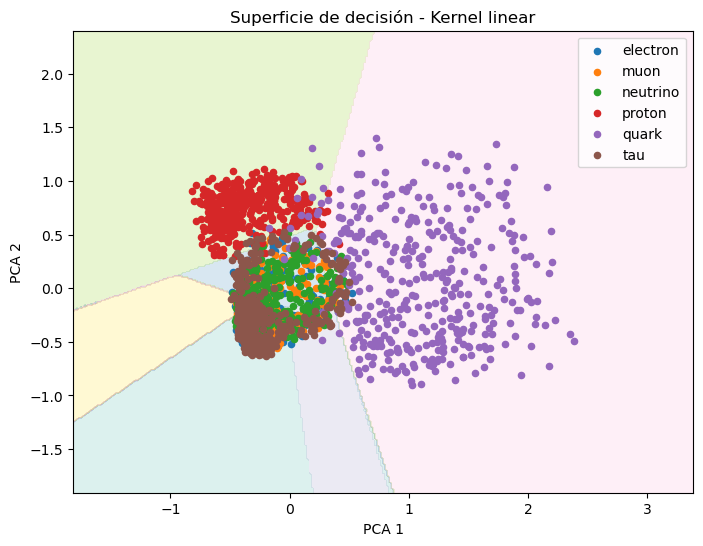

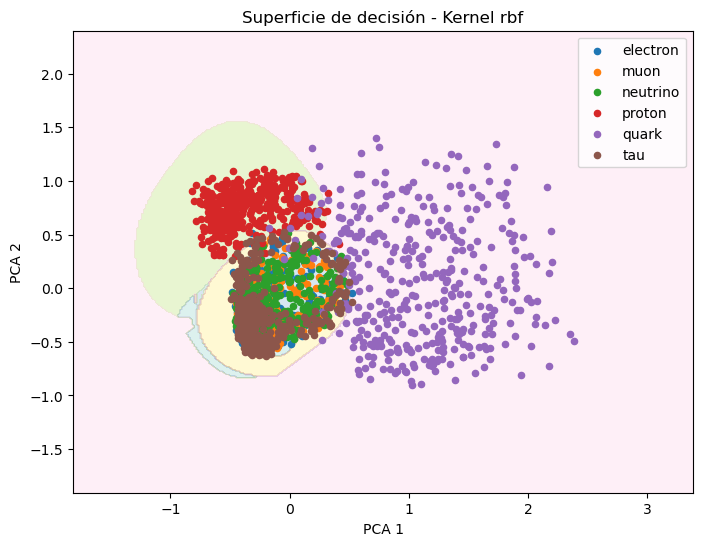

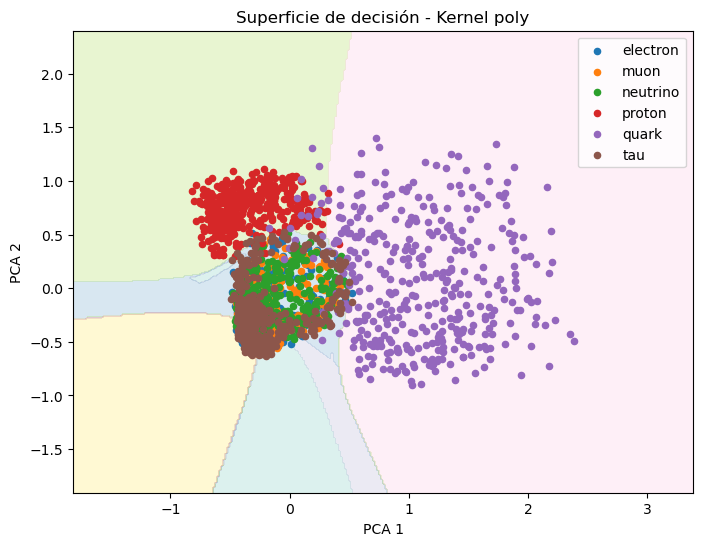

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC
from sklearn.decomposition import PCA

# Reducimos a 2D
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Convertimos etiquetas a números
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)

# Definimos kernels
kernels = ["linear", "rbf", "poly"]

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

for kernel in kernels:
    clf = SVC(kernel=kernel, C=10, gamma="scale", degree=3)
    clf.fit(X_train_pca, y_train_enc)
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)  # Ahora Z es numérico (int)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set3)

    # Graficamos puntos de entrenamiento con su clase real
    for i, cls in enumerate(le.classes_):
        idx = np.where(y_train_enc == i)
        plt.scatter(X_train_pca[idx, 0], X_train_pca[idx, 1], label=cls, s=20)

    plt.title(f"Superficie de decisión - Kernel {kernel}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.show()


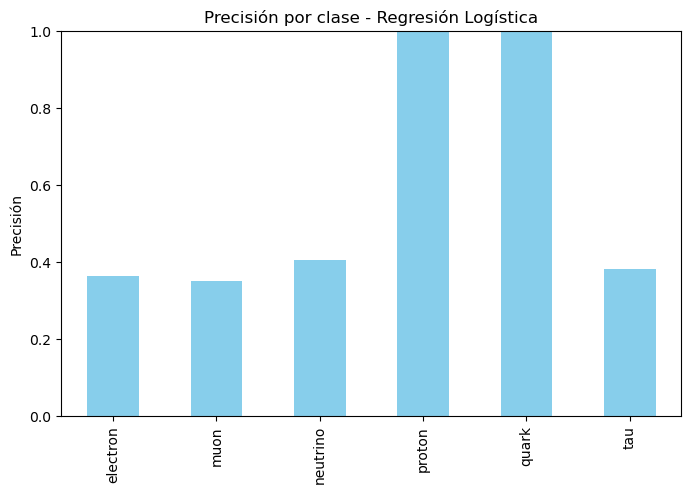

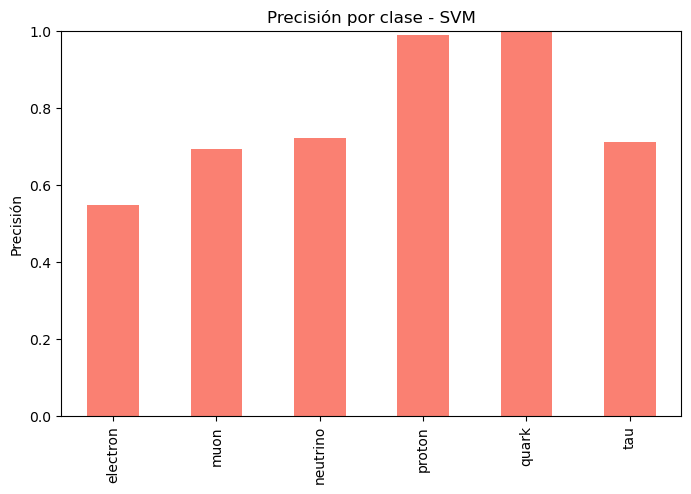

In [17]:
from sklearn.metrics import classification_report
import pandas as pd

# --- Logistic Regression ---
report_lr = classification_report(y_test, y_pred_lr, output_dict=True, target_names=classes)
df_lr = pd.DataFrame(report_lr).transpose()

plt.figure(figsize=(8,5))
df_lr.loc[classes, "precision"].plot(kind="bar", color="skyblue")
plt.title("Precisión por clase - Regresión Logística")
plt.ylabel("Precisión")
plt.ylim(0,1)
plt.show()

# --- SVM ---
report_svm = classification_report(y_test, y_pred_svm, output_dict=True, target_names=classes)
df_svm = pd.DataFrame(report_svm).transpose()

plt.figure(figsize=(8,5))
df_svm.loc[classes, "precision"].plot(kind="bar", color="salmon")
plt.title("Precisión por clase - SVM")
plt.ylabel("Precisión")
plt.ylim(0,1)
plt.show()


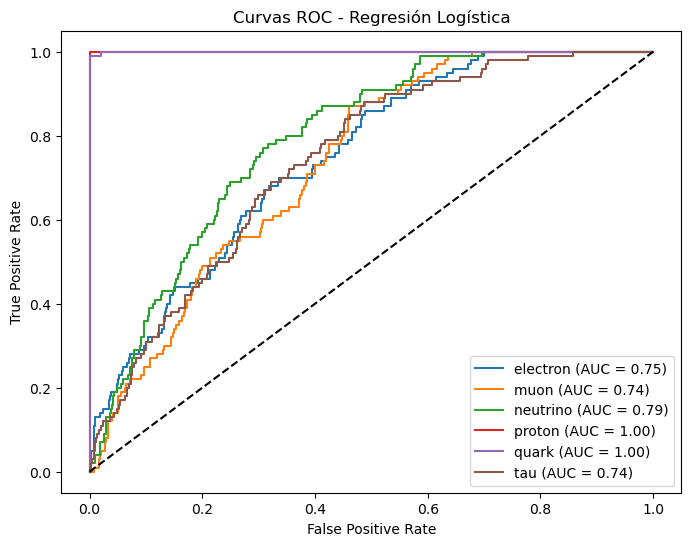

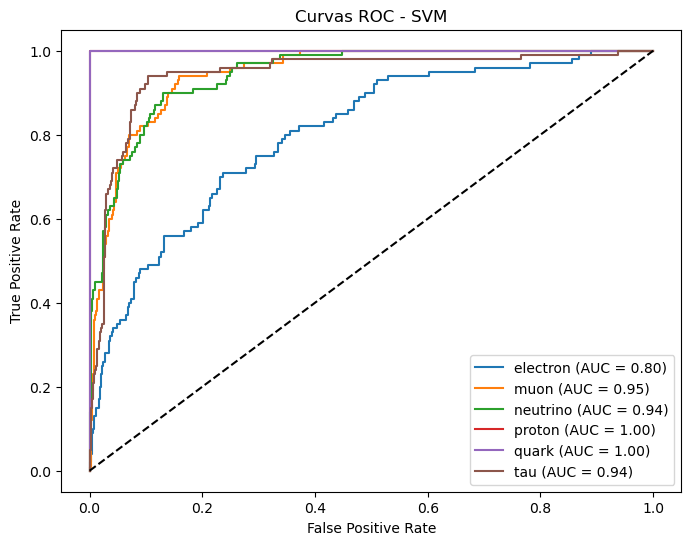

In [18]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

# Binarizar las etiquetas (necesario para ROC multiclase)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# --- Regresión Logística ---
clf_lr = OneVsRestClassifier(LogisticRegression(max_iter=2000, solver="lbfgs"))
clf_lr.fit(X_train, y_train)
y_score_lr = clf_lr.decision_function(X_test)

# --- SVM ---
clf_svm = OneVsRestClassifier(SVC(kernel="rbf", C=10, gamma="scale", probability=True))
clf_svm.fit(X_train, y_train)
y_score_svm = clf_svm.decision_function(X_test)

# Función para graficar ROC
def plot_multiclass_roc(y_test_bin, y_score, classes, title):
    plt.figure(figsize=(8,6))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {roc_auc:.2f})")
    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.show()

# Graficar ROC para ambos modelos
plot_multiclass_roc(y_test_bin, y_score_lr, classes, "Curvas ROC - Regresión Logística")
plot_multiclass_roc(y_test_bin, y_score_svm, classes, "Curvas ROC - SVM")
